<a href="https://colab.research.google.com/github/umair594/Remote-internship_DS_CodeAlpha/blob/main/Unemployment%20Analysis%20with%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unemployment Analysis with Python**

**Introduction**

This project focuses on analyzing the unemployment rate, which represents the percentage of people who are unemployed.

**Objectives:**

Analyze unemployment trends over time

Study the impact of COVID-19

Identify patterns and seasonal trends

Provide insights for economic and social policies

# **Understanding the Dataset**

**The dataset contains the following columns:**

Region → State/Area name

Date → Time of observation

Estimated Unemployment Rate (%) → Target variable

Estimated Employed → Number of employed people

Labour Participation Rate (%) → Workforce
participation

Area → Rural / Urban

# **Step 1: Data Loading**

In [14]:
import pandas as pd

df = pd.read_csv("Unemployment in India.csv")
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


**Purpose:**

Load the dataset into Python

# **Step 2: Data Cleaning**

In [15]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort data by date
df = df.sort_values('Date')

# **Step 3: Exploratory Data Analysis (EDA)**

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 48.0+ KB
None


In [18]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

In [20]:
# Checking Missing Values
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


### **Imputing Missing Values**

In [ ]:
# Impute numerical columns with median
for col in ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Impute categorical columns with mode
for col in ['Region', 'Area']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple values, so take the first
        df[col].fillna(mode_val, inplace=True)

# Impute 'Date' and 'Frequency' using ffill and bfill for sequential data
df['Date'].fillna(method='ffill', inplace=True)
df['Date'].fillna(method='bfill', inplace=True)
df['Frequency'].fillna(method='ffill', inplace=True)
df['Frequency'].fillna(method='bfill', inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

In [22]:
# Again check Missing values
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


# **Step 4: Unemployment Trend Over Time**

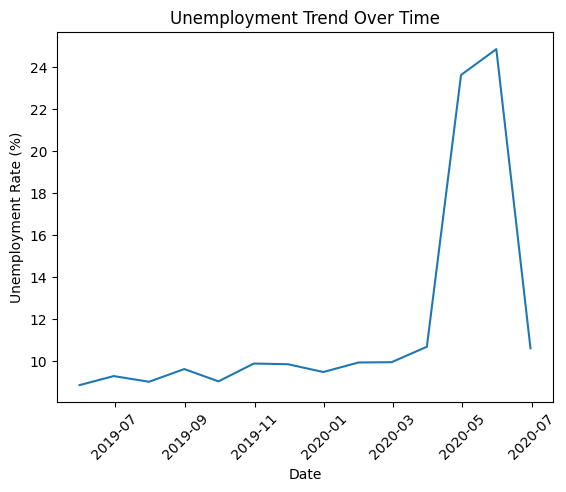

In [23]:
import matplotlib.pyplot as plt

trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure()
plt.plot(trend.index, trend.values)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Trend Over Time")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Unemployment was stable in 2019

Sharp increase observed in 2020

# **Step 5: COVID-19 Impact Analysis**

In [24]:
pre_covid = df[df['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()

print("Before COVID:", pre_covid)
print("After COVID:", post_covid)

Before COVID: 9.509533582089553
After COVID: 16.636939655172416


# **Step 6: Rural vs Urban Analysis**

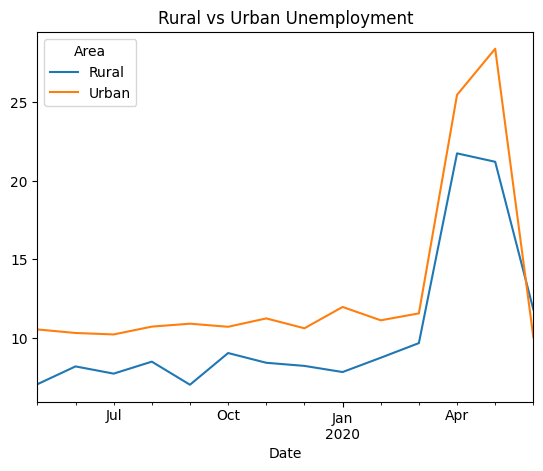

In [25]:
area_trend = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().unstack()

area_trend.plot()
plt.title("Rural vs Urban Unemployment")
plt.show()

# **Step 7: Seasonal Trends**

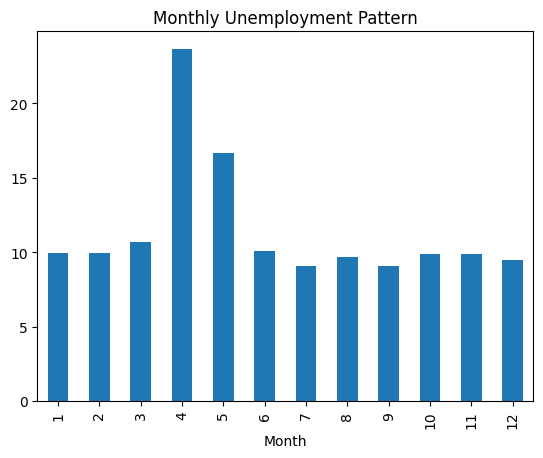

In [26]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot(kind='bar')
plt.title("Monthly Unemployment Pattern")
plt.show()

# **Step 8: Region-wise Analysis**

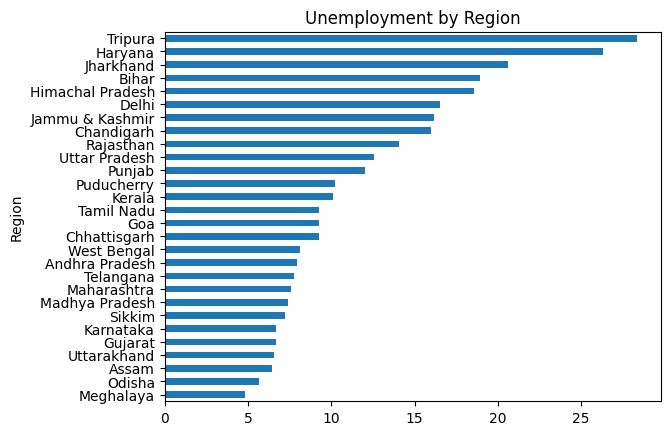

In [27]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()

region_avg.plot(kind='barh')
plt.title("Unemployment by Region")
plt.show()

# **Key Insights**

**COVID Impact**

Sudden spike in unemployment

Lockdowns caused job losses

**Urban Impact**

Cities were hit harder due to industry shutdowns

**Seasonal Patterns**

Employment varies due to seasonal work

**Regional Differences**

Uneven economic development across regions

# **Policy Recommendations**

**Based on the analysis:**

Governments should create employment programs

Support small businesses during crises

Invest in rural development

Improve economic resilience planning

# **Viva / Presentation Explanation**

We analyzed unemployment data using Python by performing data cleaning, visualization, and trend analysis. The results showed a significant rise in unemployment during COVID-19, especially in urban areas. We also identified seasonal and regional patterns, which can help in economic planning and policymaking.

# **Tools Used**

Python

Pandas

Matplotlib

# **Conclusion**

**This project demonstrates:**

✔ Importance of data cleaning

✔ Power of data visualization

✔ Real-world impact of data science